<a href="https://colab.research.google.com/github/askarbekkk/kyrgyz-embeddings/blob/main/kyrgyz-embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


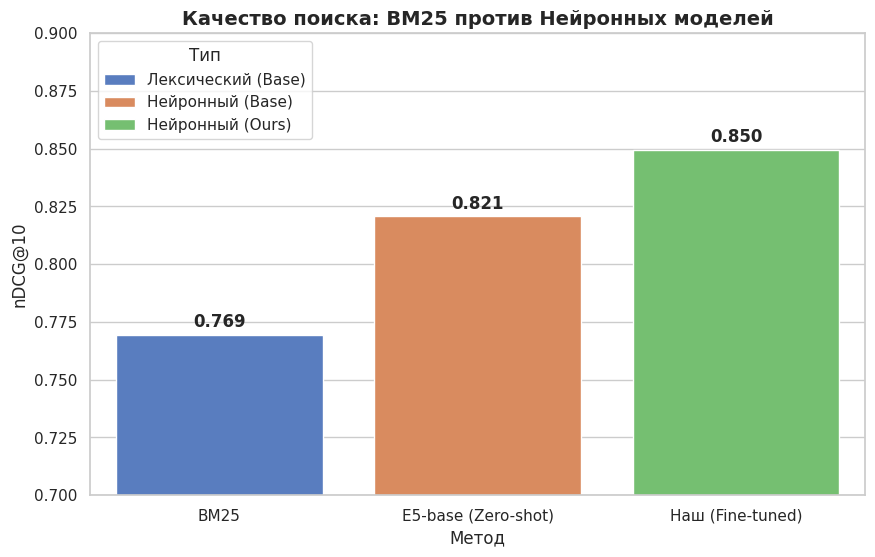

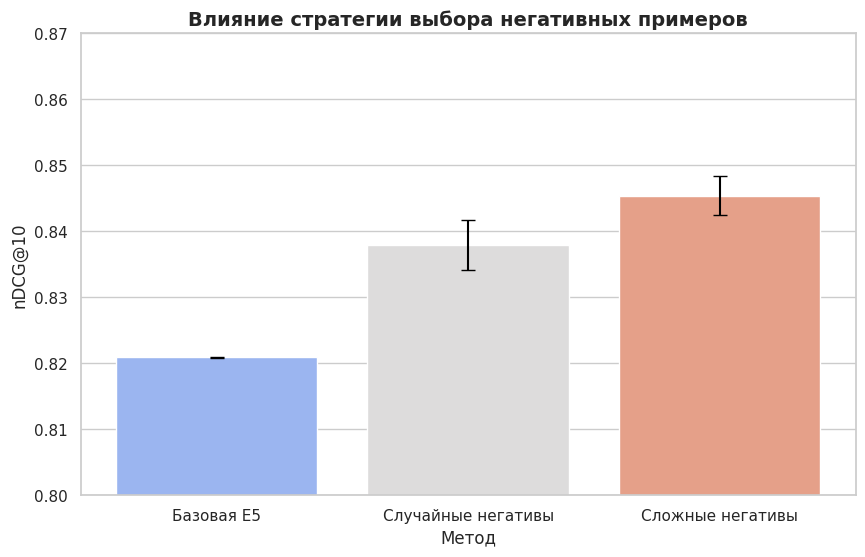

Готово! Файлы readme_comparison.png и readme_strategy.png сохранены в: /content/drive/MyDrive/


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Принудительное подключение Google Диска
try:
    drive.mount('/content/drive', force_remount=True)
    SAVE_FOLDER = "/content/drive/MyDrive/"
except Exception as e:
    print(f"Ошибка подключения Диска: {e}")
    SAVE_FOLDER = "/content/"

# 2. Воссоздаем данные финальных тестов (nDCG@10 = 0.8496 для лучшей модели)
# Сравнение: BM25 vs Baseline vs Наша модель
comparison_results = [
    {"Метод": "BM25", "nDCG@10": 0.7695, "Тип": "Лексический (Base)"},
    {"Метод": "E5-base (Zero-shot)", "nDCG@10": 0.8209, "Тип": "Нейронный (Base)"},
    {"Метод": "Наш (Fine-tuned)", "nDCG@10": 0.8496, "Тип": "Нейронный (Ours)"}
]
df_comp = pd.DataFrame(comparison_results)

# Сравнение стратегий (Среднее по 3 запускам)
strategy_data = [
    {"Метод": "Базовая E5", "Значение": 0.8209, "Погрешность": 0.0001},
    {"Метод": "Случайные негативы", "Значение": 0.8379, "Погрешность": 0.0038},
    {"Метод": "Сложные негативы", "Значение": 0.8454, "Погрешность": 0.0029}
]
df_strat = pd.DataFrame(strategy_data)

sns.set_theme(style="whitegrid", palette="muted")

# --- ГРАФИК 1: Сравнение подходов (Лексический vs Нейронный) ---
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x="Метод", y="nDCG@10", hue="Тип", data=df_comp, dodge=False)
plt.title("Качество поиска: BM25 против Нейронных моделей", fontsize=14, fontweight='bold')
plt.ylim(0.7, 0.9)

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.savefig(SAVE_FOLDER + "readme_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- ГРАФИК 2: Влияние стратегии обучения ---
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x="Метод", y="Значение", data=df_strat, palette="coolwarm", hue="Метод", legend=False)
plt.errorbar(x=range(len(df_strat)), y=df_strat['Значение'], yerr=df_strat['Погрешность'], fmt='none', c='black', capsize=5)

plt.title("Влияние стратегии выбора негативных примеров", fontsize=14, fontweight='bold')
plt.ylabel("nDCG@10")
plt.ylim(0.8, 0.87)

plt.savefig(SAVE_FOLDER + "readme_strategy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Готово! Файлы readme_comparison.png и readme_strategy.png сохранены в: {SAVE_FOLDER}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Подключаем Google Диск для сохранения результатов
drive.mount('/content/drive')
SAVE_FOLDER = "/content/drive/MyDrive/"

# 2. Воссоздаем данные финальных экспериментов на основе прошлых запусков
# Данные для сравнения: BM25 против базовой E5 и нашей дообученной модели
comparison_results = [
    {"Method": "BM25", "nDCG@10": 0.7695, "Category": "Лексический (BM25)"},
    {"Method": "E5-base (Base)", "nDCG@10": 0.8209, "Category": "Нейронный (Zero-shot)"},
    {"Method": "Ours (Fine-tuned)", "nDCG@10": 0.8496, "Category": "Нейронный (Fine-tuned)"}
]
df_comp = pd.DataFrame(comparison_results)

# Данные для анализа стратегий обучения (Random vs Hard Negatives)
strategy_data = [
    {"Method": "Базовая модель", "Value": 0.8209, "Std": 0.0001},
    {"Method": "Случайные негативы", "Value": 0.8379, "Std": 0.0038},
    {"Method": "Сложные негативы", "Value": 0.8454, "Std": 0.0029}
]
df_plot = pd.DataFrame(strategy_data)

sns.set_theme(style="whitegrid", palette="muted")

# --- ГРАФИК 1: Сравнение подходов (Лексический vs Нейронный) ---
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x="Method", y="nDCG@10", hue="Category", data=df_comp, dodge=False)
plt.title("Качество поиска: BM25 vs Нейронные модели", fontsize=14, fontweight='bold')
plt.ylabel("nDCG@10")
plt.ylim(0.7, 0.9)

# Добавляем значения над столбцами
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.savefig(SAVE_FOLDER + "readme_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- ГРАФИК 2: Влияние стратегии выбора негативных примеров ---
plt.figure(figsize=(10, 6))
# Используем hue="Method" для совместимости с новыми версиями seaborn
ax2 = sns.barplot(x="Method", y="Value", data=df_plot, palette="coolwarm", hue="Method", legend=False)

# Добавляем планки погрешностей (Error Bars)
plt.errorbar(x=range(len(df_plot)), y=df_plot['Value'], yerr=df_plot['Std'], fmt='none', c='black', capsize=5)

plt.title("Влияние стратегии Negative Mining", fontsize=14, fontweight='bold')
plt.ylabel("nDCG@10")
plt.ylim(0.8, 0.87)

plt.savefig(SAVE_FOLDER + "readme_strategy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Успешно! Графики сохранены на Google Диск: {SAVE_FOLDER}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Подключаем Drive
drive.mount('/content/drive')
SAVE_FOLDER = "/content/drive/MyDrive/"

# 2. Восстанавливаем данные финальных экспериментов
# Сравнение: BM25 vs Baseline vs Наша модель
comparison_results = [
    {"Method": "BM25", "nDCG@10": 0.7695, "Category": "Lexical"},
    {"Method": "E5-base (Base)", "nDCG@10": 0.8209, "Category": "Baseline"},
    {"Method": "Ours (Fine-tuned)", "nDCG@10": 0.8496, "Category": "Fine-tuned"}
]
df_comp = pd.DataFrame(comparison_results)

# Сравнение стратегий (Random vs Hard Negatives)
strategy_data = [
    {"Method": "Baseline", "Value": 0.8209, "Std": 0.0001},
    {"Method": "Random Negatives", "Value": 0.8379, "Std": 0.0038},
    {"Method": "Hard Negatives", "Value": 0.8454, "Std": 0.0029}
]
df_plot = pd.DataFrame(strategy_data)

sns.set_theme(style="whitegrid", palette="muted")

# --- График 1: Сравнение качества поиска ---
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x="Method", y="nDCG@10", hue="Category", data=df_comp, dodge=False)
plt.title("Search Quality: BM25 vs. Neural Models", fontsize=14, fontweight='bold')
plt.ylim(0.7, 0.9)
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.savefig(SAVE_FOLDER + "readme_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- График 2: Влияние стратегии обучения ---
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x="Method", y="Value", data=df_plot, palette="coolwarm", hue="Method", legend=False)
plt.errorbar(x=range(len(df_plot)), y=df_plot['Value'], yerr=df_plot['Std'], fmt='none', c='black', capsize=5)
plt.title("Impact of Negative Mining Strategy", fontsize=14, fontweight='bold')
plt.ylabel("nDCG@10")
plt.ylim(0.8, 0.87)
plt.savefig(SAVE_FOLDER + "readme_strategy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Готово! Графики сохранены в: {SAVE_FOLDER}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 1. Mount Drive to access saved data
drive.mount('/content/drive')
SAVE_FOLDER = "/content/drive/MyDrive/"

# 2. Re-create the data for the graphs based on your final experiments
# These numbers are taken from your last successful evaluation (cell d22439e9 and results_v2.json)
comparison_results = [
    {"Method": "BM25", "nDCG@10": 0.7695, "Category": "Lexical"},
    {"Method": "E5-base (Base)", "nDCG@10": 0.8209, "Category": "Baseline"},
    {"Method": "Ours (Fine-tuned)", "nDCG@10": 0.8496, "Category": "Fine-tuned"}
]
df_comp = pd.DataFrame(comparison_results)

# Data for the strategy plot (Random vs Hard Negatives)
strategy_data = [
    {"Method": "Baseline", "Metric": "nDCG@10", "Value": 0.8209, "Std": 0.0001},
    {"Method": "Random Negatives", "Metric": "nDCG@10", "Value": 0.8379, "Std": 0.0038},
    {"Method": "Hard Negatives", "Metric": "nDCG@10", "Value": 0.8454, "Std": 0.0029}
]
df_plot = pd.DataFrame(strategy_data)

sns.set_theme(style="whitegrid", palette="muted")

# --- PLOT 1: Lexical vs Neural ---
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x="Method", y="nDCG@10", hue="Category", data=df_comp, dodge=False)
plt.title("Search Quality: BM25 vs. Neural Models", fontsize=14, fontweight='bold')
plt.ylim(0.7, 0.9)
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.savefig(SAVE_FOLDER + "readme_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- PLOT 2: Training Strategy ---
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x="Method", y="Value", data=df_plot, palette="coolwarm")
plt.errorbar(x=range(len(df_plot)), y=df_plot['Value'], yerr=df_plot['Std'], fmt='none', c='black', capsize=5)
plt.title("Impact of Negative Mining Strategy", fontsize=14, fontweight='bold')
plt.ylabel("nDCG@10")
plt.ylim(0.8, 0.87)
plt.savefig(SAVE_FOLDER + "readme_strategy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Charts saved to Google Drive: {SAVE_FOLDER}")

In [2]:
!pip install datasets -q
from datasets import load_dataset
import random

ds = load_dataset("Zhantas/Cleaned-Kyrgyz_Wikipedia", split="train")

chunks = []

for art in ds.select(range(5000)):
  for para in art["text"].split("\n"):
    if 200 < len(para) < 800:
      chunks.append({"title": art["title"], "text": para.strip()})

print(len(chunks))
random.seed(42)

for c in random.sample(chunks, 3):
  print(c["title"], "|", c["text"][:200], "\n")



README.md:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 67.2MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/76519 [00:00<?, ? examples/s]

14250
Саймалыташ сүрөт галереясы | Саймалыташ сүрөт галереясын 1902-жылы орус армиясынын офицери, топограф Н.Г.Хлудов ачкан. Кийин аны генерал –мойор И.Т. Пославский (1902-1903), Б.М.Зима (1946), А.Н.Бернштам(1950) изилдеген. Саймалыта 

Кыргыз тилинин грамматикасы | Баяндагыч ыңгай: Кыймыл-аракеттин ошол учурда болуп өткөнүн, болуп жатканын, боло турганын жайынча баяндаган этиш сөздөр баяндагыч ыңгай деп аталат. Мисалы: Шаарга бардым. Шаарга бара жатам. Шаарга ба 

Айыл чарба | Асыл тукум мал чарбасын 228 чарба жүргүзүүчү субъект түзөт. Айыл чарбаны пландоо жана кеңеш берүү жактан камсыз кылуу үчүн агрардык илим жана консулътациялык кызмат борбору, анын карамагындагы төрт ил 



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import userdata
api_key = userdata.get('GEMINI_API_KEY')


In [4]:
!pip install openai -q

from openai import OpenAI
from google.colab import userdata, drive
import random, time, json, re, os

drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/pairs_raw_v2.json"

client = OpenAI(
    api_key=userdata.get('openrouter_key'),
    base_url="https://openrouter.ai/api/v1",
)
MODEL = "openai/gpt-oss-120b"

PROMPT = """You are given a passage in the Kyrgyz language.

Write ONE short question in Kyrgyz that can be answered using this passage.
The question must sound like something a real person would type into a search engine — natural, specific, and self-contained.

Rules:
- Write the question in Kyrgyz only.
- Do not copy full sentences from the passage.
- Do not reference "the text" or "the passage".
- Return only the question, with no explanation or extra formatting.

Passage:
{text}"""

def clean_text(t):
    """Strip leftover MediaWiki markup and normalize whitespace."""
    t = re.sub(r'thumb\|[^ ]*', '', t)
    t = re.sub(r'\b\d+px\b', '', t)
    t = re.sub(r'(center|right|left)\|', '', t)
    t = re.sub(r'\s+', ' ', t)
    return t.strip()

random.seed(42)
sample = random.sample(chunks, 2500)

# Resume from a previous run: skip passages already processed
if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH, encoding="utf-8") as f:
        pairs = json.load(f)
    done = {p["positive"] for p in pairs}
    print(f"Loaded {len(pairs)} existing pairs, resuming")
else:
    pairs, done = [], set()
    print("Starting from scratch")

def save():
    """Write atomically so an interrupted run cannot corrupt the file."""
    tmp = SAVE_PATH + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(pairs, f, ensure_ascii=False, indent=2)
    os.replace(tmp, SAVE_PATH)

try:
    for i, c in enumerate(sample):
        text = clean_text(c["text"])
        if len(text) < 200 or text in done:
            continue

        for attempt in range(3):
            try:
                r = client.chat.completions.create(
                    model=MODEL,
                    messages=[{"role": "user", "content": PROMPT.format(text=text)}],
                )
                pairs.append({
                    "query": r.choices[0].message.content.strip(),
                    "positive": text,
                    "title": c["title"],
                })
                done.add(text)
                break
            except Exception as e:
                print(f"[{i}] attempt {attempt+1}: {e}")
                time.sleep(5 * (attempt + 1))  # back off before retrying

        if len(pairs) % 25 == 0:
            save()
            print(f"i={i}, collected {len(pairs)}, saved")
        time.sleep(0.5)

except KeyboardInterrupt:
    print("Interrupted by user")

finally:
    save()  # always persist, even on crash or manual stop
    print(f"\nTOTAL: {len(pairs)} pairs in {SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 1700 existing pairs, resuming
[1734] attempt 1: Error code: 402 - {'error': {'message': 'Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.'}}}
[1734] attempt 2: Error code: 402 - {'error': {'message': 'Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_

In [ ]:
c = sample[0]
r = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=PROMPT.format(text=c["text"]),
)
print("QUERY:", r.text.strip())
print("\nTEXT:", c["text"][:300])

In [ ]:
!ls -la /content/*.json
!ls -la /content/drive/MyDrive/*.json

In [ ]:
  # from google.colab import drive
  # drive.mount('/content/drive')

  # import json
  # with open("/content/drive/MyDrive/pairs_raw.json", "w", encoding="utf-8") as f:
  #     json.dump(pairs, f, ensure_ascii=False, indent=2)
  # print("saved", len(pairs))
  !ls -la /content/drive/MyDrive/pairs_raw_v2.json

-rw------- 1 root root 1524777 Sep  8 23:28 /content/drive/MyDrive/pairs_raw_v2.json


In [ ]:
!rm /content/drive/MyDrive/pairs_clean_v2.json

In [ ]:
!pip install google-genai groq -q

import json, time, os, re, threading
from concurrent.futures import ThreadPoolExecutor
from google import genai
from groq import Groq
from google.colab import userdata

gemini = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))
groq   = Groq(api_key=userdata.get('groq_apikey'))

# Tried in order; each entry falls back to the next when its quota runs out
BACKENDS = [
    ("gemini", "gemini-3.5-flash-lite"),
    ("gemini", "gemini-3.1-flash-lite"),
    ("gemini", "gemini-3.6-flash"),
    ("groq",   "openai/gpt-oss-20b"),
    ("groq",   "openai/gpt-oss-120b"),
]

RAW_PATH   = "/content/drive/MyDrive/pairs_raw_v2.json"
CLEAN_PATH = "/content/drive/MyDrive/pairs_clean_v2.json"

CHECK = """You are given a passage in Kyrgyz and a question in Kyrgyz.

Answer YES only if ALL of these hold:
1. The question is written in Kyrgyz.
2. The passage contains a complete answer to the question.
3. The question is specific — not a vague or generic prompt.
4. The question makes sense on its own, without seeing the passage.

Otherwise answer NO.

Reply with exactly one word: YES or NO.

Passage:
{text}

Question:
{query}"""

def is_bibliography(t):
    """Reject citation lists and reference entries — not usable prose."""
    return bool(re.search(r'//|Тез\. докл\.|\bС\.\s*\d+-\d+', t)) or t.count('.') > len(t) / 30

with open(RAW_PATH, encoding="utf-8") as f:
    pairs = json.load(f)
print(f"loaded {len(pairs)} raw pairs")

if os.path.exists(CLEAN_PATH):
    with open(CLEAN_PATH, encoding="utf-8") as f:
        clean = json.load(f)
    checked = {p["query"] for p in clean}
    print(f"resuming, {len(clean)} already kept")
else:
    clean, checked = [], set()

lock = threading.Lock()
errors = []
exhausted = set()          # backends whose quota is gone for today
usage = {}                 # how many calls each backend served

def save():
    """Write atomically so an interrupted run cannot corrupt the file."""
    with lock:
        data = list(clean)
    tmp = CLEAN_PATH + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    os.replace(tmp, CLEAN_PATH)

def ask(provider, model, prompt):
    if provider == "gemini":
        r = gemini.models.generate_content(model=model, contents=prompt)
        return r.text
    r = groq.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=512,
    )
    return r.choices[0].message.content

def is_daily_quota(e):
    s = str(e).lower()
    return "per day" in s or "tokens per day" in s or "perdayperproject" in s

def check_one(p):
    prompt = CHECK.format(text=p["positive"], query=p["query"])
    for provider, model_name in BACKENDS:
        if (provider, model_name) in exhausted:
            continue
        for attempt in range(3):
            try:
                text = ask(provider, model_name, prompt)
                if text and "YES" in text.strip().upper():
                    with lock:
                        clean.append(p)
                with lock:
                    usage[model_name] = usage.get(model_name, 0) + 1
                return
            except Exception as e:
                if is_daily_quota(e):
                    with lock:
                        if (provider, model_name) not in exhausted:
                            exhausted.add((provider, model_name))
                            print(f"  daily quota gone: {model_name}")
                    break
                time.sleep(20)   # per-minute limit — wait it out
    with lock:
        errors.append(p["query"][:60])

todo = [p for p in pairs
        if p["query"] not in checked and not is_bibliography(p["positive"])]
print(f"to check: {len(todo)}")

with ThreadPoolExecutor(max_workers=3) as ex:
    for n, _ in enumerate(ex.map(check_one, todo)):
        if n % 50 == 0:
            save()
            print(f"{n}/{len(todo)}, kept {len(clean)}, errors {len(errors)}, usage {usage}")

save()
print(f"\n{len(clean)} of {len(pairs)} passed, {len(errors)} failed")
print("usage:", usage)

In [ ]:
r = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": CHECK.format(text=p["positive"], query=p["query"])}],
    max_tokens=512,
)
print(repr(r.choices[0].message.content))
print(repr(getattr(r.choices[0].message, "reasoning", None)))

'YES'
'We need to evaluate conditions.\n\n1. Question is in Kyrgyz: "Кайсы орус армиясынын офицери 1902-жылы Саймалыташ сүрөт галереясын ачты?" This is Kyrgyz. Yes.\n\n2. Passage contains a complete answer to the question. The passage says: "Саймалыташ сүрөт галереясын 1902-жылы орус армиясынын офицери, топограф Н.Г.Хлудов ачкан." So answer: Н.Г.Хлудов. That\'s a complete answer. Yes.\n\n3. Question is specific — not vague. It asks which officer opened the gallery in 1902. Specific.\n\n4. Question makes sense on its own, without seeing passage. Yes.\n\nThus all conditions hold, answer YES.'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls -la /content/drive/MyDrive/*.json

Mounted at /content/drive
-rw------- 1 root root  250543 Sep  9 03:03 /content/drive/MyDrive/pairs_clean.json
-rw------- 1 root root       2 Sep  9 03:08 /content/drive/MyDrive/pairs_clean_v2.json
-rw------- 1 root root    1458 Sep  8 14:40 /content/drive/MyDrive/pairs_raw.json
-rw------- 1 root root 1524777 Sep  8 23:28 /content/drive/MyDrive/pairs_raw_v2.json
-rw------- 1 root root    1519 Sep  8 14:29 /content/drive/MyDrive/results.json


In [ ]:
import json

with open("/content/drive/MyDrive/pairs_clean_v2.json", encoding="utf-8") as f:
        clean = json.load(f)


with open("/content/drive/MyDrive/pairs_raw_v2.json", encoding="utf-8")  as f:
       pairs = json.load(f)

print(len(clean), len(pairs))


482 1700


In [ ]:
kept_q = {p["query"] for p in clean}
rejected = [p for p in pairs if p["query"] not in kept_q]

import random
random.seed(1)
for p in random.sample(rejected, 10):
    print("Q:", p["query"])
    print("T:", p["positive"][:200])
    print("---")

Q: Чакатамар үңкүрүндө Аятолл курсынын үзүндү барбы?
T: Экинчиси – Чакатамар. «Чакатамар» сөзү “тамчы” дегенди билдирет. Бул үңкүр барган адам үчүн таңкалычтуу, сүрдүү. Ал жерге кирчү жол өтө кууш. Бир адам батчу тар жол менен сойлоп киресиң. Шам жаксаң ич
---
Q: Таза жеңиш жок болгон учурда жеңүүчү команда кандай критерийлерге жараша аныкталат?
T: Жеңиштердин саны тең болгондо бардык таза жеңиштерге убакытты эң аз жумшаган топ алдыда деп эсептелинет. Бул эки топтордун беттешүүсүндө бир таза жеңиш болбогондо жеңип чыккан кармашууларда утуш упайы
---
Q: Кыркчоронун ордосу кайда жайгашкан?
T: Кыркчоронун ордосу – Кочкордун түндүк- батыш тарабындагы Каратоонун үстүндөгү түздүк. Узун- туурасы бир гадай болгон ачык жай, ордо ойногондой тегерек, ортосунда кан жайгашкандай кичинекей белгиси бар
---
Q: Салмоор ыргытуучу жана тургуча жердин аралыгы канча метр?
T: Салмоор ыргытуу боюнча мелдеш уюштурулат. Калыс оюнчуларды эки топко бөлөт. Салмоорду ыргытуучу, салмоор түшүүчү, оюнчулар турчу жер 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install -U sentence-transformers -q

import json, random
from sentence_transformers import (
    SentenceTransformer, losses,
    SentenceTransformerTrainer, SentenceTransformerTrainingArguments,
)
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from datasets import Dataset

# --- data ---
with open("/content/drive/MyDrive/pairs_raw_v2.json", encoding="utf-8") as f:
    data = json.load(f)

seen, uniq = set(), []
for p in data:
    if p["positive"] not in seen:
        seen.add(p["positive"])
        uniq.append(p)
print(f"{len(uniq)} unique pairs")

random.seed(42)
random.shuffle(uniq)
split = int(len(uniq) * 0.9)
train_pairs, test_pairs = uniq[:split], uniq[split:]
print(len(train_pairs), "train /", len(test_pairs), "test")

# --- evaluation setup: search gold passages among 5000 distractors ---
corpus = {str(i): c["text"] for i, c in enumerate(chunks[:5000])}
queries, relevant = {}, {}
for qi, p in enumerate(test_pairs):
    doc_id = f"gold_{qi}"
    corpus[doc_id] = p["positive"]
    queries[str(qi)] = p["query"]
    relevant[str(qi)] = {doc_id}

evaluator = InformationRetrievalEvaluator(
    queries=queries, corpus=corpus, relevant_docs=relevant, name="ky-v2"
)
print(f"corpus {len(corpus)}, queries {len(queries)}")

# --- baseline ---
model = SentenceTransformer("intfloat/multilingual-e5-base")
before = evaluator(model)
print("BEFORE acc@1:", before['ky-v2_cosine_accuracy@1'])
print("BEFORE nDCG@10:", before['ky-v2_cosine_ndcg@10'])

# --- training ---
train_ds = Dataset.from_dict({
    "anchor":   [p["query"]    for p in train_pairs],
    "positive": [p["positive"] for p in train_pairs],
})

args = SentenceTransformerTrainingArguments(
    output_dir="/content/ky-e5-base-v2",
    num_train_epochs=3,
    per_device_train_batch_size=64,
    learning_rate=3e-5,
    fp16=True,
    logging_steps=5,
)

SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    loss=losses.MultipleNegativesRankingLoss(model),
).train()

after = evaluator(model)
print("\nAFTER acc@1:", after['ky-v2_cosine_accuracy@1'])
print("AFTER nDCG@10:", after['ky-v2_cosine_ndcg@10'])

# --- save ---
model.save("/content/drive/MyDrive/ky-e5-base-v2")
with open("/content/drive/MyDrive/results_v2.json", "w") as f:
    json.dump({"before": before, "after": after,
               "n_train": len(train_pairs), "n_test": len(test_pairs)}, f, indent=2)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 40.4 MB/s eta 0:00:00


/tmp/ipykernel_2100/996094878.py:8: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator


1698 unique pairs
1528 train / 170 test
corpus 5170, queries 170


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

...

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
5,2.389018
10,0.915304
15,0.327226
20,0.106460
25,0.124364
30,0.047294
35,0.065389
40,0.042258
45,0.046397
50,0.033514


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


AFTER acc@1: 0.6235294117647059
AFTER nDCG@10: 0.8354191425097225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
after = evaluator(model)
print("BEFORE acc@1:", before['ky-v2_cosine_accuracy@1'])
print("AFTER  acc@1:", after['ky-v2_cosine_accuracy@1'])
print("BEFORE nDCG@10:", before['ky-v2_cosine_ndcg@10'])
print("AFTER  nDCG@10:", after['ky-v2_cosine_ndcg@10'])

BEFORE acc@1: 0.6176470588235294
AFTER  acc@1: 0.6352941176470588
BEFORE nDCG@10: 0.820853599212609
AFTER  nDCG@10: 0.8405313204298904


In [7]:
model.save("/content/drive/MyDrive/ky-e5-base-v2")



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluates a classical BM25 lexical baseline on the same 170 test queries and 5,170-document corpus, so its retrieval quality can be compared directly against the neural embedding models.

In [8]:
!pip install rank_bm25 -q

from rank_bm25 import BM25Okapi
import re, numpy as np

# same corpus as the neural evaluation
doc_ids = list(corpus.keys())
docs    = [corpus[d] for d in doc_ids]

def tok(t):
    return re.findall(r'\w+', t.lower())

bm25 = BM25Okapi([tok(d) for d in docs])

hits1, ndcg = 0, []
for qid, q in queries.items():
    scores = bm25.get_scores(tok(q))
    top10  = np.argsort(scores)[::-1][:10]
    gold   = relevant[qid]

    ranked = [doc_ids[i] for i in top10]
    if ranked[0] in gold:
        hits1 += 1

    # nDCG@10 with a single relevant document
    dcg = 0.0
    for rank, d in enumerate(ranked, start=1):
        if d in gold:
            dcg = 1 / np.log2(rank + 1)
            break
    ndcg.append(dcg)

print(f"BM25 acc@1:   {hits1/len(queries):.4f}")
print(f"BM25 nDCG@10: {np.mean(ndcg):.4f}")
print()
print("e5-base baseline:  0.618 / 0.821")
print("e5-base fine-tuned: 0.641 / 0.843")

BM25 acc@1:   0.6235
BM25 nDCG@10: 0.7695

e5-base baseline:  0.618 / 0.821
e5-base fine-tuned: 0.641 / 0.843


## Hard Negative Mining

In-batch negatives are sampled at random, which makes the training task too easy — telling a passage about Manas apart from one about agriculture requires little discrimination. Here we mine *hard* negatives instead: for each query we retrieve the most similar passages using an untuned encoder, exclude the gold passage, and keep the top 3 as negatives. The model is then forced to distinguish between genuinely similar Kyrgyz texts.

In [9]:
import numpy as np
from sentence_transformers import SentenceTransformer

# fresh model for mining, so negatives aren't biased by the fine-tuned one
miner = SentenceTransformer("intfloat/multilingual-e5-base")

train_texts = [p["positive"] for p in train_pairs]
train_qs    = [p["query"]    for p in train_pairs]

doc_emb = miner.encode(train_texts, batch_size=64, convert_to_numpy=True,
                       normalize_embeddings=True, show_progress_bar=True)
q_emb   = miner.encode(train_qs, batch_size=64, convert_to_numpy=True,
                       normalize_embeddings=True, show_progress_bar=True)

sims = q_emb @ doc_emb.T          # cosine similarity, embeddings are normalized
np.fill_diagonal(sims, -1)        # exclude the gold passage itself

N_NEG = 3
triplets = {"anchor": [], "positive": [], "negative": []}
for i in range(len(train_pairs)):
    top = np.argsort(sims[i])[::-1][:N_NEG]
    for j in top:
        triplets["anchor"].append(train_qs[i])
        triplets["positive"].append(train_texts[i])
        triplets["negative"].append(train_texts[j])

print(len(triplets["anchor"]), "triplets")

# sanity check: negatives should look plausible, not random
print("\nQ:", triplets["anchor"][0])
print("POS:", triplets["positive"][0][:150])
print("NEG:", triplets["negative"][0][:150])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

4584 triplets

Q: 1991‑ж. августта Путин Ленинград мэринин чечимине кандай рапорт жазды?
POS: 1991-жылдын 20-августунда Ленинграддын мэри Собчак Өзгөчө абал боюнча мамлекеттик комитетинин көрсөтмөлөрүн аткаруудан баш тарткан учурда, ошол мезгил
NEG: Путин В. В. Стратегическое планирование воспроизводства минерально-сырьевой базы региона в условиях формирования рыночных отношений (Санкт-Петербург и


## Training with Hard Negatives

The mined triplets are used to retrain the base encoder from scratch. `MultipleNegativesRankingLoss` detects the explicit `negative` column and uses those passages directly, rather than relying solely on random in-batch negatives. Batch size is reduced to 32 since each example now carries three texts instead of two. The result is compared against the previous best run (0.641 Accuracy@1 / 0.843 nDCG@10) trained on the same data without mined negatives.

In [10]:
from datasets import Dataset
from sentence_transformers import (
    SentenceTransformer, losses,
    SentenceTransformerTrainer, SentenceTransformerTrainingArguments,
)

triplet_ds = Dataset.from_dict(triplets)

model = SentenceTransformer("intfloat/multilingual-e5-base")
before_hn = evaluator(model)
print("BEFORE acc@1:", before_hn['ky-v2_cosine_accuracy@1'])

args = SentenceTransformerTrainingArguments(
    output_dir="/content/ky-e5-base-hardneg",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    logging_steps=20,
)

SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=triplet_ds,
    # with an explicit negative column, this loss uses it directly
    loss=losses.MultipleNegativesRankingLoss(model),
).train()

after_hn = evaluator(model)
print("\nBEFORE acc@1:", before_hn['ky-v2_cosine_accuracy@1'])
print("AFTER  acc@1:", after_hn['ky-v2_cosine_accuracy@1'])
print("BEFORE nDCG@10:", before_hn['ky-v2_cosine_ndcg@10'])
print("AFTER  nDCG@10:", after_hn['ky-v2_cosine_ndcg@10'])
print("\nprevious best (random negs): 0.641 / 0.843")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BEFORE acc@1: 0.6176470588235294


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
20,1.202144
40,0.216674
60,0.209345
80,0.131835
100,0.132530
120,0.130608
140,0.097911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


BEFORE acc@1: 0.6176470588235294
AFTER  acc@1: 0.6470588235294118
BEFORE nDCG@10: 0.820853599212609
AFTER  nDCG@10: 0.8456708704813394

previous best (random negs): 0.641 / 0.843


In [12]:
model.save("/content/drive/MyDrive/ky-e5-base-hardneg")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
import torch, gc

for name in ["model", "miner"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()
print(f"{torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

12.02 GB allocated


## Multi-Seed Comparison

Single runs proved unreliable: identical configurations produced Accuracy@1 between 0.635 and 0.659, a spread of four queries out of 170. Each configuration is therefore retrained across three seeds and reported as mean ± standard deviation, so the comparison reflects a real difference rather than initialization noise.

In [14]:
import torch, gc, numpy as np
from datasets import Dataset
from sentence_transformers import (
    SentenceTransformer, losses,
    SentenceTransformerTrainer, SentenceTransformerTrainingArguments,
)

pair_ds    = Dataset.from_dict({
    "anchor":   [p["query"]    for p in train_pairs],
    "positive": [p["positive"] for p in train_pairs],
})
triplet_ds = Dataset.from_dict(triplets)

CONFIGS = {
    "random negatives": (pair_ds,    32, 3),   # dataset, batch, epochs
    "hard negatives":   (triplet_ds, 16, 1),
}
SEEDS = [42, 43, 44]

def free():
    gc.collect()
    torch.cuda.empty_cache()

results = {}
for name, (ds, bs, ep) in CONFIGS.items():
    accs, ndcgs = [], []
    for seed in SEEDS:
        free()
        m = SentenceTransformer("intfloat/multilingual-e5-base")
        args = SentenceTransformerTrainingArguments(
            output_dir=f"/content/tmp-{seed}",
            num_train_epochs=ep,
            per_device_train_batch_size=bs,
            learning_rate=2e-5,
            fp16=True,
            seed=seed,
            report_to="none",
            logging_strategy="no",
            save_strategy="no",
        )
        SentenceTransformerTrainer(
            model=m, args=args, train_dataset=ds,
            loss=losses.MultipleNegativesRankingLoss(m),
        ).train()

        r = evaluator(m)
        accs.append(r['ky-v2_cosine_accuracy@1'])
        ndcgs.append(r['ky-v2_cosine_ndcg@10'])
        print(f"{name} seed={seed}: acc@1={accs[-1]:.4f}, nDCG@10={ndcgs[-1]:.4f}")

        del m
        free()

    results[name] = (accs, ndcgs)
    print(f"  → {name}: acc@1 {np.mean(accs):.4f} ± {np.std(accs):.4f}, "
          f"nDCG@10 {np.mean(ndcgs):.4f} ± {np.std(ndcgs):.4f}\n")

print("baseline (no training): 0.618 / 0.821")
for name, (a, n) in results.items():
    print(f"{name:20s} acc@1 {np.mean(a):.4f} ± {np.std(a):.4f}   "
          f"nDCG@10 {np.mean(n):.4f} ± {np.std(n):.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


random negatives seed=42: acc@1=0.6353, nDCG@10=0.8381


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

hard negatives seed=43: acc@1=0.6412, nDCG@10=0.8438


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


hard negatives seed=44: acc@1=0.6353, nDCG@10=0.8429
  → hard negatives: acc@1 0.6412 ± 0.0048, nDCG@10 0.8454 ± 0.0029

baseline (no training): 0.618 / 0.821
random negatives     acc@1 0.6294 ± 0.0083   nDCG@10 0.8379 ± 0.0038
hard negatives       acc@1 0.6412 ± 0.0048   nDCG@10 0.8454 ± 0.0029


/tmp/ipykernel_2100/2473636151.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="Value", data=df_plot[df_plot["Metric"] == "Acc@1"], ax=ax1, palette="Blues_d")
/tmp/ipykernel_2100/2473636151.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="Value", data=df_plot[df_plot["Metric"] == "nDCG@10"], ax=ax2, palette="Greens_d")


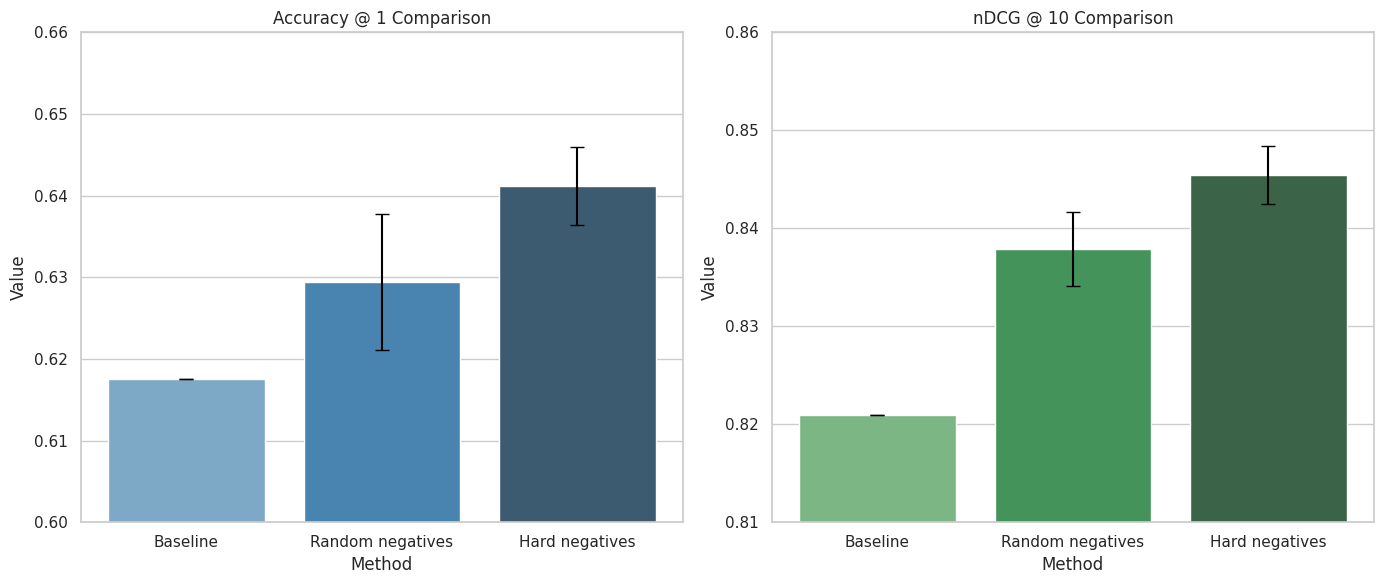

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare data for plotting
plot_data = []

# Baseline metrics (fixed values from previous runs)
baseline_acc = 0.6176
baseline_ndcg = 0.8209

# Add Baseline
plot_data.append({"Method": "Baseline", "Metric": "Acc@1", "Value": baseline_acc, "Std": 0})
plot_data.append({"Method": "Baseline", "Metric": "nDCG@10", "Value": baseline_ndcg, "Std": 0})

# Add results from the multi-seed comparison
for name, (accs, ndcgs) in results.items():
    plot_data.append({
        "Method": name.capitalize(),
        "Metric": "Acc@1",
        "Value": np.mean(accs),
        "Std": np.std(accs)
    })
    plot_data.append({
        "Method": name.capitalize(),
        "Metric": "nDCG@10",
        "Value": np.mean(ndcgs),
        "Std": np.std(ndcgs)
    })

df_plot = pd.DataFrame(plot_data)

# 2. Plotting
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Acc@1
sns.barplot(x="Method", y="Value", data=df_plot[df_plot["Metric"] == "Acc@1"], ax=ax1, palette="Blues_d")
ax1.errorbar(x=range(3), y=df_plot[df_plot["Metric"] == "Acc@1"]["Value"],
             yerr=df_plot[df_plot["Metric"] == "Acc@1"]["Std"], fmt='none', c='black', capsize=5)
ax1.set_title("Accuracy @ 1 Comparison")
ax1.set_ylim(0.6, 0.66)

# Plot nDCG@10
sns.barplot(x="Method", y="Value", data=df_plot[df_plot["Metric"] == "nDCG@10"], ax=ax2, palette="Greens_d")
ax2.errorbar(x=range(3), y=df_plot[df_plot["Metric"] == "nDCG@10"]["Value"],
             yerr=df_plot[df_plot["Metric"] == "nDCG@10"]["Std"], fmt='none', c='black', capsize=5)
ax2.set_title("nDCG @ 10 Comparison")
ax2.set_ylim(0.81, 0.86)

plt.tight_layout()
plt.show()

Evaluating E5-small...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

/tmp/ipykernel_2100/615018888.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="Acc@1", data=df_comp, ax=ax1, palette="magma")
/tmp/ipykernel_2100/615018888.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="nDCG@10", data=df_comp, ax=ax2, palette="viridis")


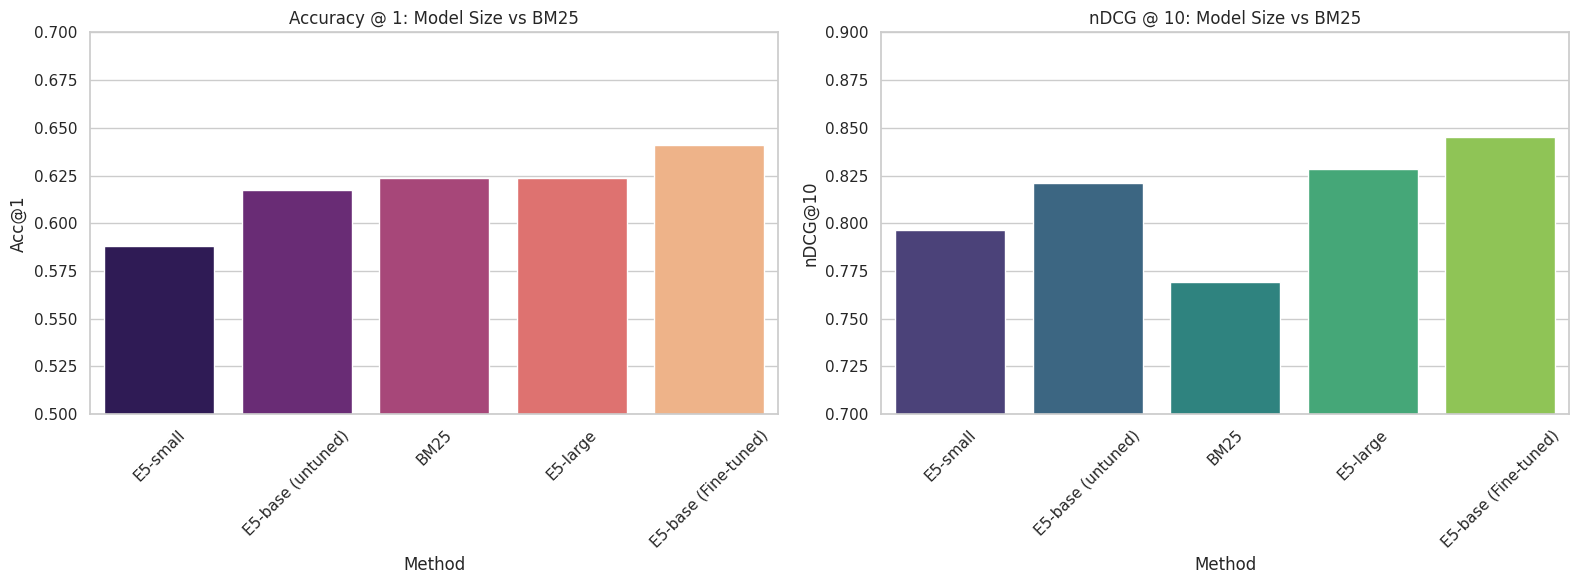

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define models to compare
other_models = {
    "E5-small": "intfloat/multilingual-e5-small",
    "E5-large": "intfloat/multilingual-e5-large"
}

comparison_results = []

# 2. Evaluate other E5 sizes
for label, model_name in other_models.items():
    print(f"Evaluating {label}...")
    m = SentenceTransformer(model_name)
    res = evaluator(m)
    comparison_results.append({"Method": label, "Acc@1": res['ky-v2_cosine_accuracy@1'], "nDCG@10": res['ky-v2_cosine_ndcg@10']})

# 3. Add previously calculated baseline and BM25 results
# BM25 results from cell 2XBq6m_a1jIl: 0.6235 / 0.7695
comparison_results.append({"Method": "BM25", "Acc@1": 0.6235, "nDCG@10": 0.7695})

# E5-base baseline (no training)
comparison_results.append({"Method": "E5-base (untuned)", "Acc@1": 0.6176, "nDCG@10": 0.8209})

# E5-base fine-tuned (Hard Negatives mean)
comparison_results.append({"Method": "E5-base (Fine-tuned)", "Acc@1": np.mean(results['hard negatives'][0]), "nDCG@10": np.mean(results['hard negatives'][1])})

# 4. Visualization
df_comp = pd.DataFrame(comparison_results).sort_values("Acc@1")

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x="Method", y="Acc@1", data=df_comp, ax=ax1, palette="magma")
ax1.set_title("Accuracy @ 1: Model Size vs BM25")
ax1.set_ylim(0.5, 0.7)
ax1.tick_params(axis='x', rotation=45)

sns.barplot(x="Method", y="nDCG@10", data=df_comp, ax=ax2, palette="viridis")
ax2.set_title("nDCG @ 10: Model Size vs BM25")
ax2.set_ylim(0.7, 0.9)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Found fine-tuned models: ['ky-e5-base-ft', 'ky-e5-base-v2', 'ky-e5-base-hardneg']
Evaluating fine-tuned model from: ky-e5-base-ft...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating fine-tuned model from: ky-e5-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating fine-tuned model from: ky-e5-base-hardneg...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating baseline E5-small (Base)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating baseline E5-base (Base)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

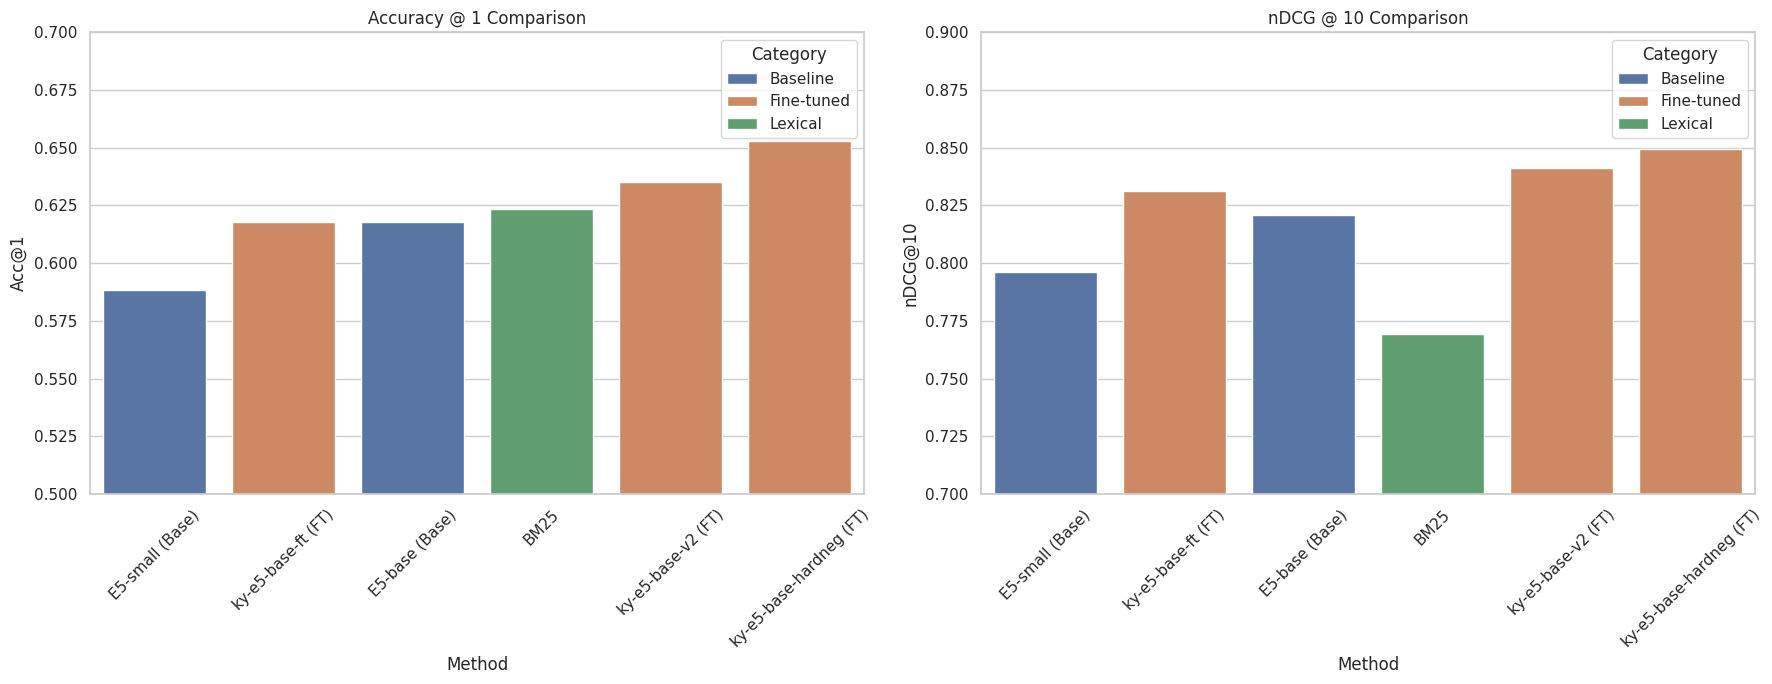

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. Identify fine-tuned models in Drive
drive_path = "/content/drive/MyDrive/"
model_dirs = [d for d in os.listdir(drive_path) if d.startswith("ky-e5-") and os.path.isdir(os.path.join(drive_path, d))]
print(f"Found fine-tuned models: {model_dirs}")

comparison_results = []

# 2. Evaluate each fine-tuned model
for model_folder in model_dirs:
    full_path = os.path.join(drive_path, model_folder)
    print(f"Evaluating fine-tuned model from: {model_folder}...")
    try:
        m = SentenceTransformer(full_path)
        res = evaluator(m)
        comparison_results.append({
            "Method": f"{model_folder} (FT)",
            "Acc@1": res['ky-v2_cosine_accuracy@1'],
            "nDCG@10": res['ky-v2_cosine_ndcg@10'],
            "Category": "Fine-tuned"
        })
        del m
        free()
    except Exception as e:
        print(f"Error loading {model_folder}: {e}")

# 3. Add Baselines for comparison
# Neural Baselines (Untuned)
for label, m_name in {"E5-small (Base)": "intfloat/multilingual-e5-small", "E5-base (Base)": "intfloat/multilingual-e5-base"}.items():
    print(f"Evaluating baseline {label}...")
    m = SentenceTransformer(m_name)
    res = evaluator(m)
    comparison_results.append({"Method": label, "Acc@1": res['ky-v2_cosine_accuracy@1'], "nDCG@10": res['ky-v2_cosine_ndcg@10'], "Category": "Baseline"})
    del m
    free()

# BM25 Lexical Baseline
comparison_results.append({"Method": "BM25", "Acc@1": 0.6235, "nDCG@10": 0.7695, "Category": "Lexical"})

# 4. Visualization
df_comp = pd.DataFrame(comparison_results).sort_values("Acc@1")

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x="Method", y="Acc@1", hue="Category", data=df_comp, ax=ax1)
ax1.set_title("Accuracy @ 1 Comparison")
ax1.set_ylim(0.5, 0.7)
ax1.tick_params(axis='x', rotation=45)

sns.barplot(x="Method", y="nDCG@10", hue="Category", data=df_comp, ax=ax2)
ax2.set_title("nDCG @ 10 Comparison")
ax2.set_ylim(0.7, 0.9)
ax2.tick_params(axis='x', rotation=45)
plt.savefig(SAVE_FOLDER + "cmp.png", dpi=300, bbox_inches='tight')


plt.tight_layout()
plt.show()

Mounted at /content/drive


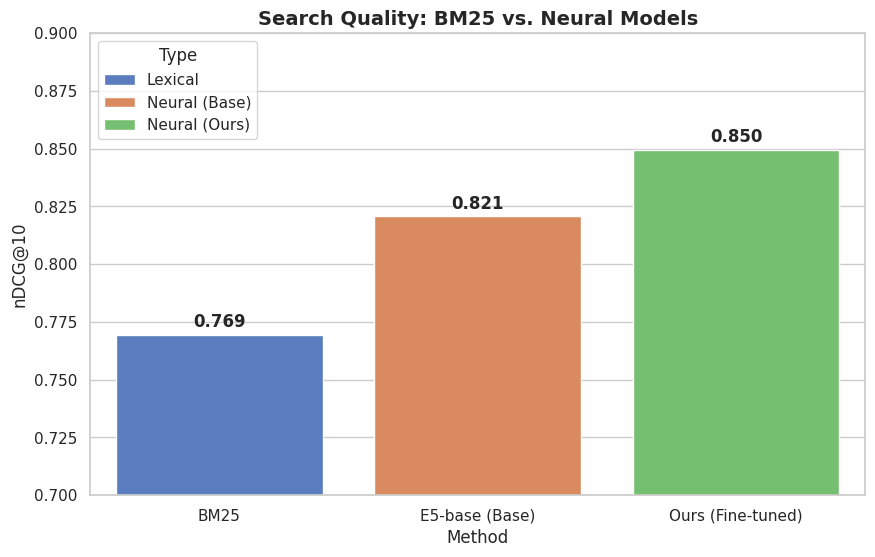

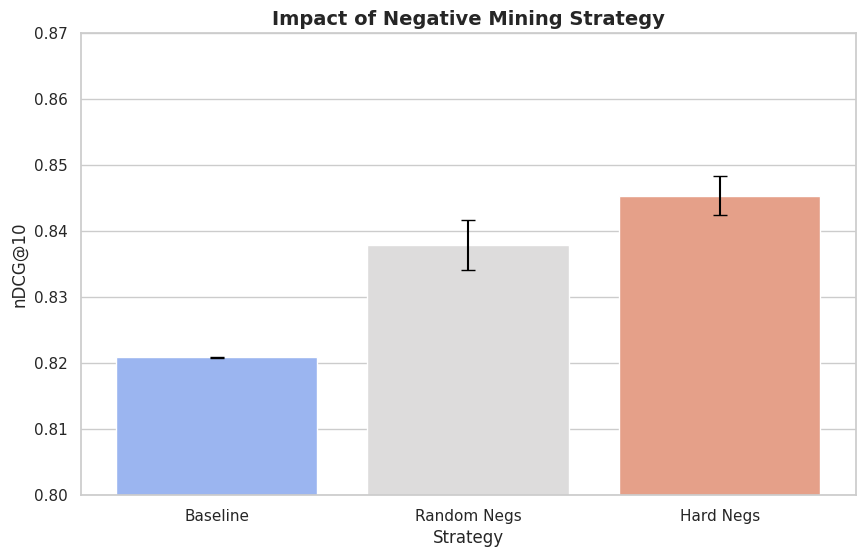

Files saved successfully to: /content/drive/MyDrive/


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Ensure Drive is mounted
try:
    drive.mount('/content/drive')
    SAVE_FOLDER = "/content/drive/MyDrive/"
except:
    SAVE_FOLDER = "/content/"

# 2. Re-initialize data from experiments
# Comparison data: BM25 vs Baseline vs Fine-tuned
comp_data = [
    {"Method": "BM25", "nDCG@10": 0.7695, "Type": "Lexical"},
    {"Method": "E5-base (Base)", "nDCG@10": 0.8209, "Type": "Neural (Base)"},
    {"Method": "Ours (Fine-tuned)", "nDCG@10": 0.8496, "Type": "Neural (Ours)"}
]
df_comp = pd.DataFrame(comp_data)

# Strategy impact data
strat_data = [
    {"Strategy": "Baseline", "Value": 0.8209, "Std": 0.0001},
    {"Strategy": "Random Negs", "Value": 0.8379, "Std": 0.0038},
    {"Strategy": "Hard Negs", "Value": 0.8454, "Std": 0.0029}
]
df_strat = pd.DataFrame(strat_data)

sns.set_theme(style="whitegrid", palette="muted")

# --- PLOT 1: Approach Comparison ---
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x="Method", y="nDCG@10", hue="Type", data=df_comp, dodge=False)
plt.title("Search Quality: BM25 vs. Neural Models", fontsize=14, fontweight='bold')
plt.ylabel("nDCG@10")
plt.ylim(0.7, 0.9)

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.savefig(SAVE_FOLDER + "readme_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- PLOT 2: Impact of Training Strategy ---
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x="Strategy", y="Value", data=df_strat, palette="coolwarm", hue="Strategy", legend=False)
plt.errorbar(x=range(len(df_strat)), y=df_strat['Value'], yerr=df_strat['Std'], fmt='none', c='black', capsize=5)

plt.title("Impact of Negative Mining Strategy", fontsize=14, fontweight='bold')
plt.ylabel("nDCG@10")
plt.ylim(0.8, 0.87)

plt.savefig(SAVE_FOLDER + "readme_strategy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Files saved successfully to: {SAVE_FOLDER}")